In [100]:
import pandas as pd
from sklearn import datasets

wine = datasets.load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

df.head(20)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0


In [101]:
print("Sınıf sayısı:", len(wine.target_names))
print("Sınıf isimleri:", wine.target_names)
print("Her sınıftan kaç örnek var:\n", pd.Series(wine.target).value_counts().sort_index())

Sınıf sayısı: 3
Sınıf isimleri: ['class_0' 'class_1' 'class_2']
Her sınıftan kaç örnek var:
 0    59
1    71
2    48
Name: count, dtype: int64


In [102]:
df['class'] = wine.target
print("\nİlk 10 satır (class ile birlikte):")
df.sample(10)


İlk 10 satır (class ile birlikte):


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
24,13.50,1.81,2.61,20.0,96.0,2.53,2.61,0.28,1.66,3.52,1.12,3.82,845.0,0
81,12.72,1.81,2.20,18.8,86.0,2.20,2.53,0.26,1.77,3.90,1.16,3.14,714.0,1
88,11.64,2.06,2.46,21.6,84.0,1.95,1.69,0.48,1.35,2.80,1.00,2.75,680.0,1
50,13.05,1.73,2.04,12.4,92.0,2.72,3.27,0.17,2.91,7.20,1.12,2.91,1150.0,0
131,12.88,2.99,2.40,20.0,104.0,1.30,1.22,0.24,0.83,5.40,0.74,1.42,530.0,2
28,13.87,1.90,2.80,19.4,107.0,2.95,2.97,0.37,1.76,4.50,1.25,3.40,915.0,0
136,12.25,4.72,2.54,21.0,89.0,1.38,0.47,0.53,0.80,3.85,0.75,1.27,720.0,2
34,13.51,1.80,2.65,19.0,110.0,2.35,2.53,0.29,1.54,4.20,1.10,2.87,1095.0,0
143,13.62,4.95,2.35,20.0,92.0,2.00,0.80,0.47,1.02,4.40,0.91,2.05,550.0,2
105,12.42,2.55,2.27,22.0,90.0,1.68,1.84,0.66,1.42,2.70,0.86,3.30,315.0,1


In [103]:
features = df.drop(columns=['class']).columns.to_list()
labels = 'class'

X, y = df[features].values, df[labels].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set boyutu: {X_train.shape[0]}")
print(f"Test set boyutu: {X_test.shape[0]}")

Training set boyutu: 142
Test set boyutu: 36


In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

reg = 0.01

model = LogisticRegression(C=1/reg, solver='lbfgs', max_iter=10000).fit(X_train, y_train)

pred = model.predict(X_test)

print("Model eğitildi.")
print(f"Accuracy score: {accuracy_score(y_test, pred)}")

Model eğitildi.
Accuracy score: 1.0


In [105]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]


In [106]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [107]:
from sklearn.metrics import recall_score, precision_score, f1_score

print("Recall:", recall_score(y_test, pred, average='macro'))
print("Precision:", precision_score(y_test, pred, average='macro'))
print("F1 Score:", f1_score(y_test, pred, average='macro'))

Recall: 1.0
Precision: 1.0
F1 Score: 1.0


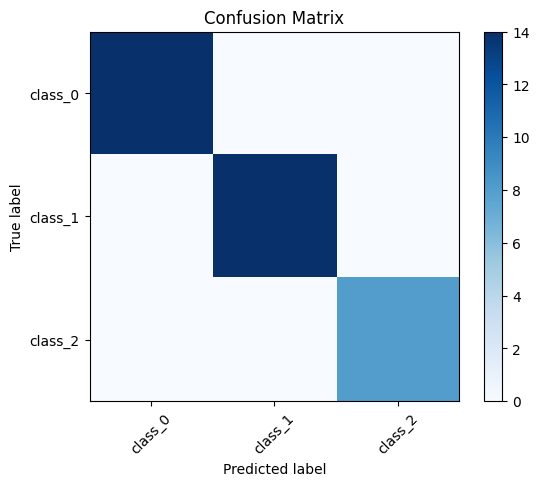

In [108]:
import matplotlib.pyplot as plt
import numpy as np

# interpolation='nearest' => Piksel değerleri keskin olsun
# cmap=plt.cm.Blues => Mavi tonlarında bir renk haritası kullan
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

# Sağ tarafta renk çubuğu
plt.colorbar()

tick_marks = np.arange(len(wine.target_names))

plt.xticks(tick_marks, wine.target_names, rotation=45)
plt.yticks(tick_marks, wine.target_names)

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

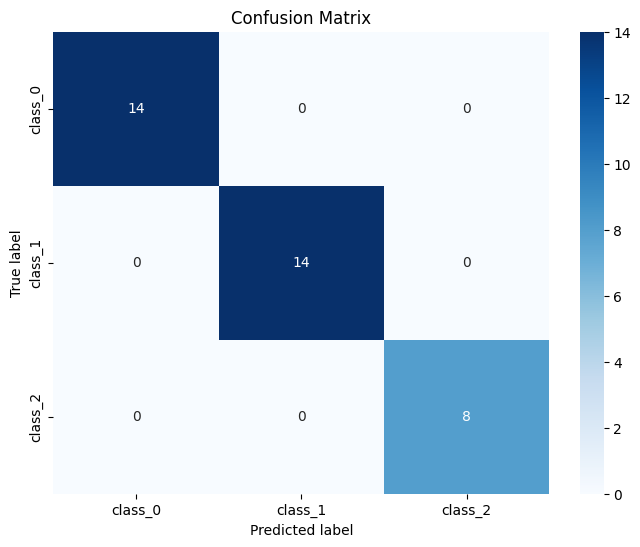

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
# Seaborn ile daha güzel bir görselleştirme
# annnot=True => Sayıları hücrelerin içine yaz
# fmt='d' => Sayıları tam sayı olarak göster
# cmap='Blues' => Mavi tonlarında renk haritası
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

In [110]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Average cross-validation score:", np.mean(cv_scores))

Cross-validation scores: [1.         0.89655172 0.92857143 0.92857143 0.96428571]
Average cross-validation score: 0.9435960591133006


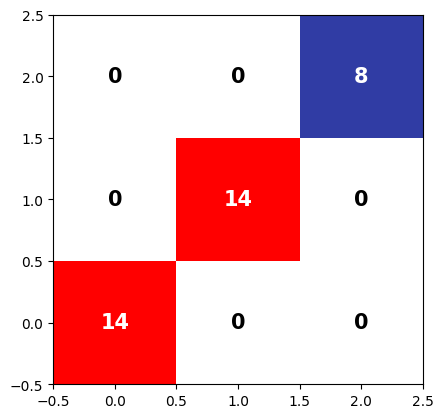

In [111]:
# Çok detaylı renk kontrolü
plt.imshow(cm, interpolation='bicubic', alpha=0.8)  # Transparency ekle
plt.imshow(cm, vmin=0, vmax=10)  # Min-max değerleri manuel ayarla

# Karmaşık renk haritaları
from matplotlib.colors import LinearSegmentedColormap
colors = ['white', 'lightblue', 'darkblue', 'red']
custom_cmap = LinearSegmentedColormap.from_list('custom', colors)
plt.imshow(cm, cmap=custom_cmap)

# Her hücreyi ayrı ayrı customize et
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, str(cm[i, j]), 
                ha='center', va='center', 
                color='white' if cm[i, j] > 5 else 'black',
                fontsize=15, fontweight='bold')

# Çok spesifik görünüm ayarları
plt.gca().set_xlim(-0.5, 2.5)  # Eksen sınırları
plt.gca().invert_yaxis()       # Y eksenini ters çevir